# Ejemplo QPM:

$$ \min_{x_1,x_2} x_1+x_2 $$
$$ \text{s.t. } x_1^2+x_2^2-2 = 0$$

In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
x1 = np.linspace(-2,2,500)
x2 = np.linspace(-2,2,500)
x1v, x2v = np.meshgrid(x1, x2)

In [21]:
f = lambda x1,x2: x1+x2 #funcion objetivo
c = lambda x1,x2: x1**2+x2**2-2 #Restriccion

In [22]:
Q = lambda x1,x2,u: f(x1,x2) +1/(2*u)*(c(x1,x2))**2

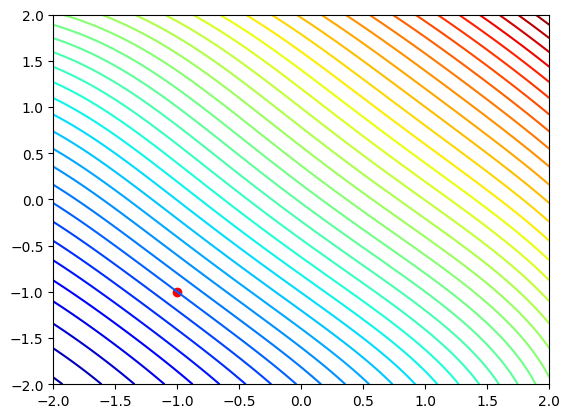

In [23]:
fig,ax=plt.subplots()
ax.cla()

CS = ax.contour(x1v, x2v, Q(x1v,x2v,50), levels = 50, cmap=plt.cm.jet)
ax.scatter(-1,-1,c = 'r')

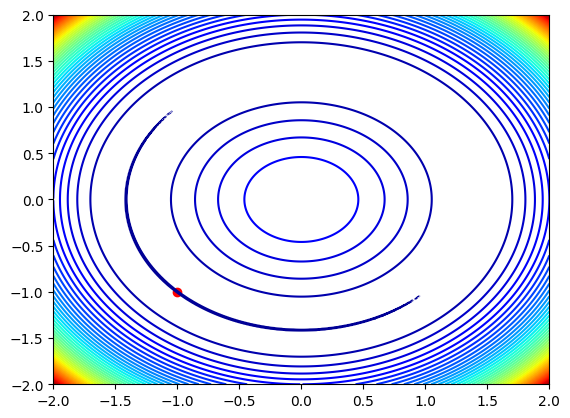

In [24]:
fig,ax=plt.subplots()
ax.cla()

CS = ax.contour(x1v, x2v, Q(x1v,x2v,0.0001), levels = 50, cmap=plt.cm.jet)
ax.scatter(-1,-1,c = 'r')

In [25]:
import scipy.optimize as sp

f = lambda x: x[0]+x[1] #funcion objetivo
c = lambda x: x[0]**2+x[1]**2-2 #Restriccion
Q = lambda x,u: f(x) + 1/(2*u)*(c(x))**2
gQ = lambda x,u: np.array([1.+1/u*c(x)*(2*x[0]), 1.+1/u*c(x)*(2*x[1])])

def qpm(x0, mu):
    # Optimizacio sin restrcciones usando el metodo BFGS
    res = sp.minimize(Q, x0, args=(mu), method='BFGS', jac=gQ)

    return res.x, res.fun

In [26]:
gQ(np.array([1,5]),100)

array([1.48, 3.4 ])

In [27]:
mu = 10
x0 = np.array([-1,-1])

# tolerancia de aceptacion en la violacion de la restriccion en el optimo
vol = 1e-15
rest_viol = True

it = 0

print ("{:<10} {:<10} {:<20} {:^20} {:^30}".format('iter','mu','minimum','condition nr.', 'constraint violation'))
while rest_viol:
    it=it+1

    xmin, fun = qpm(x0,mu)
    #xmin = x0.copy()
    print ("{:<10d} {:<10.3e} [{:^8.4f}, {:^8.4f}] {:<4} {:^20.3e}".format(it,mu,xmin[0],xmin[1],' ',c(xmin)))

    if abs(c(xmin))<=vol:
        rest_viol = False

    # Actualizacion siguiente iteracion
    mu = mu/2
    x0 = xmin

iter       mu         minimum                 condition nr.          constraint violation     
1          1.000e+01  [-1.6006 , -1.6006 ]           3.124e+00      
2          5.000e+00  [-1.3804 , -1.3804 ]           1.811e+00      
3          2.500e+00  [-1.2283 , -1.2283 ]           1.018e+00      
4          1.250e+00  [-1.1299 , -1.1299 ]           5.532e-01      
5          6.250e-01  [-1.0705 , -1.0705 ]           2.919e-01      
6          3.125e-01  [-1.0370 , -1.0370 ]           1.507e-01      
7          1.562e-01  [-1.0190 , -1.0190 ]           7.667e-02      
8          7.812e-02  [-1.0096 , -1.0096 ]           3.869e-02      
9          3.906e-02  [-1.0048 , -1.0048 ]           1.944e-02      
10         1.953e-02  [-1.0024 , -1.0024 ]           9.742e-03      
11         9.766e-03  [-1.0012 , -1.0012 ]           4.877e-03      
12         4.883e-03  [-1.0006 , -1.0006 ]           2.440e-03      
13         2.441e-03  [-1.0003 , -1.0003 ]           1.220e-03      
14      

In [28]:
xmin[0]

np.float64(-1.0000000000000002)

$$ c(x) \leq 0$$

In [29]:
max(0,2)

2

$$ \min_{x_1,x_2} f(x_1,x_2) = (x_1+0.2)^2+(x_2-1.6)^2, $$
$$ \text{s.t.} \quad  x_1^2+x_2^2-2= 0. $$
$$ \quad \quad  (x_1-0.707)^2+(x_2-0.707)^2-1 \leq 0. $$

In [30]:
import scipy.optimize as sp

f = lambda x: (x[0]+0.2)**2+(x[1]-1.6)**2 #funcion objetivo
c1 = lambda x: x[0]**2+x[1]**2-2 #Restriccion
c2 = lambda x: (x[0]-0.707)**2+(x[1]-0.707)**2-1 #Restriccion
Q = lambda x,u: f(x) + 1/(2*u)*((c1(x))**2+(max(0,c2(x)))**2)

def qpm(x0, mu):
    # Optimizacio sin restrcciones usando el metodo BFGS
    res = sp.minimize(Q, x0, args=(mu), method='BFGS')

    return res.x, res.fun

In [31]:
mu = 10
x0 = np.array([-1,-1])

# tolerancia de aceptacion en la violacion de la restriccion en el optimo
vol = 1e-15
rest_viol = True

it = 0

while rest_viol and it<500:
    it=it+1

    xmin, fun = qpm(x0,mu)
    print (f"{it}, {mu}, {xmin}, {c1(xmin)}, {c2(xmin)})")

    if abs(c1(xmin))<=vol and c2(xmin)<=vol:
        rest_viol = False

    # Actualizacion siguiente iteracion
    mu = mu/2
    x0 = xmin

1, 10, [-0.15947907  1.5172873 ], 0.327594324337273, 0.40735148980687796)
2, 5.0, [-0.13951709  1.4841856 ], 0.22227190444621225, 0.32060862931387746)
3, 2.5, [-0.11620513  1.45441306], 0.12882097133336678, 0.23629296784505271)
4, 1.25, [-0.09083112  1.43322544], 0.06238544614731323, 0.16393787768462476)
5, 0.625, [-0.06531318  1.42144688], 0.024777036843171008, 0.10690198778398496)
6, 0.3125, [-0.04264003  1.41635831], 0.007889043321931855, 0.06514939601407543)
7, 0.15625, [-0.02540555  1.41464736], 0.0018726071969012992, 0.03718268446591422)
8, 0.078125, [-0.01410221  1.41421167], 0.00019352816693629649, 0.02013674757603434)
9, 0.0390625, [-0.00747164  1.41414764], -0.0001306343018081524, 0.01052750463028973)
10, 0.01953125, [-0.00385216  1.4141628 ], -0.00012872367175020827, 0.005390030937190371)
11, 0.009765625, [-0.00195676  1.41418352], -8.115479229520162e-05, 0.002728209329391884)
12, 0.0048828125, [-9.86263709e-04  1.41419734e+00], -4.49039871175394e-05, 0.0013726307209256383)


# ALM:

$$\min [1.5-x_1(1-x_2)]^2+[2.25 -x_1(1-x_2^2)]^2+[2.625-x_1(1-x_2^3)]^2 $$

In [32]:
f = lambda x: (1.5-x[0]*(1.0-x[1]))**2+(2.25-x[0]*(1.0-x[1]**2))**2+(2.625-x[0]*(1-x[1]**3))**2 #funcion objetivo
c = lambda x: x[0]**2+x[1]**2-1 #Restriccion

L = lambda x,lam,u: f(x) + lam*c(x)+1/(2*u)*c(x)**2

def ALM(x0, lam, mu):
    # Optimizacio sin restrcciones usando el metodo BFGS
    res = sp.minimize(L, x0, args=(lam,mu), method='BFGS')

    return res.x, res.fun

In [36]:
mu = 0.1
lam = 0
x0 = np.array([np.sqrt(2)/2,np.sqrt(2)/2])

# tolerancia de aceptacion en la violacion de la restriccion en el optimo
vol = 1e-6
rest_viol = True

it = 0

while rest_viol and it<500:
    it=it+1

    xmin, fun = ALM(x0,lam,mu)
    print (f"{it}, {mu}, {xmin}, {c(xmin)}")

    if abs(c(xmin))<=vol:
        rest_viol = False

    # Actualizacion siguiente iteracion
    lam = lam + c(x0)/mu
    mu = mu/2
    x0 = xmin

1, 0.1, [ 1.12175418 -0.06977528], 0.2632010398406903
2, 0.05, [ 1.06793363 -0.07409162], 0.14597180447170843
3, 0.025, [ 0.9745607  -0.07795195], -0.044154938618909845
4, 0.0125, [ 0.94922778 -0.0782247 ], -0.09284751887745957
5, 0.00625, [ 0.98392231 -0.07776917], -0.025848837974533856
6, 0.003125, [ 1.01340469 -0.07689919], 0.03290256017303661
7, 0.0015625, [ 1.01166668 -0.07696301], 0.029392784170548802
8, 0.00078125, [ 0.99615372 -0.07746298], -0.0016772538801402836
9, 0.000390625, [ 0.9891682  -0.07764752], -0.015517127140671216
10, 0.0001953125, [ 0.99351026 -0.07753616], -0.006925507816530008
11, 9.765625e-05, [ 0.99915208 -0.07737791], 0.004292214948770967
12, 4.8828125e-05, [ 0.99981223 -0.07735733], 0.0056086448708914105
13, 2.44140625e-05, [ 0.99732758 -0.07743575], 0.0006585940961214565
14, 1.220703125e-05, [ 0.99575218 -0.07747681], -0.0024749316077453676
15, 6.103515625e-06, [ 0.99620749 -0.07748513], -0.0015666896331885116
16, 3.0517578125e-06, [ 0.99722009 -0.07749935]

In [38]:
f(xmin), xmin, lam, mu

(np.float64(4.421243067074325),
 array([ 0.99401599, -0.109237  ]),
 np.float64(327268.00758243643),
 5.820766091346741e-12)

In [35]:
f([0.997,-0.07744])

4.415203779362475